# Un arma nuclear escondida en el espacio.

¿Cómo la encuentras sin abrir el satélite?

La respuesta llevaba millones de años ahí arriba: los protones del cinturón de Van Allen.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** Danagoulian et al. (2026), *Verification of the Outer Space Treaty with cosmic protons* — Nature  
**DOI:** [10.1038/s41586-026-10783-2](https://doi.org/10.1038/s41586-026-10783-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-09-verificacion-tratado-espacial-neutrones/notebook.ipynb)

**Video:** _(pendiente)_

## El detector ya estaba puesto — y es natural

En 1967, 117 países firmaron el Tratado del Espacio Exterior: nada de armas nucleares en órbita. El problema es que nadie publicó **cómo comprobar** que se cumple — no existía un método de verificación en la literatura científica abierta.

El cinturón interno de Van Allen es una trampa de partículas: protones de casi mil millones de electronvoltios (≈1 GeV) girando alrededor de la Tierra desde hace millones de años. Cuando uno de esos protones golpea material pesado y denso —como el de una ojiva termonuclear— le arranca neutrones. A eso se le llama *spallation* (astillamiento nuclear).

La idea del paper: un detector del tamaño de un CubeSat 9U, volando cerca, podría *ver* ese brillo de neutrones. Un aviso desde ya: es un **estudio conceptual y de viabilidad**. Nadie ha construido ni volado el detector — todo lo que sigue son simulaciones y cálculos, no medidas en órbita.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DISTANCIA_M = 4000      # distancia detector–arma [metros]
N_CUBESATS  = 1         # número de detectores en la constelación

FUENTE = 'Fuente: Danagoulian et al. (2026), Nature | Datos: github.com/ustajan/kosmos'
COLOR_PROTON       = '#2563EB'
COLOR_ELECTRON     = '#BBBBBB'
COLOR_NEUTRON      = '#2563EB'
COLOR_ALERTA       = '#DC2626'
COLOR_GEV          = '#D97706'
COLOR_CONSTELACION = '#059669'

import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt

# Estilo editorial CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Ley de escala del paper (repo ustajan/kosmos, time_vs_distance):
# el tiempo de observación crece con d^2 y baja como 1/n. Los
# coeficientes son empíricos del cálculo del paper; con d=4 km y
# n=1 reproducen el titular del abstract ('~1 semana').
def tiempo_deteccion_horas(d_m, n=1):
    return (120 * np.pi * d_m**2) / ((0.3**2) * 0.77 * 0.0055 * 9.1e10) / n

# Cargar los tres espectros (dos columnas: energía [MeV], valor)
prot = np.loadtxt('datos/diff.AP9.output_mean_flux.AP9_i316.tsv')
neu  = np.loadtxt('datos/neutron_spallation.tsv')
elec = np.loadtxt('datos/diff.AE9.output_mean_flux.AE9_i316.tsv')

# El último punto de protones (2000 MeV) tiene flujo 0: fuera para log-log
prot = prot[prot[:, 1] > 0]

t_1cubesat_h = tiempo_deteccion_horas(DISTANCIA_M, N_CUBESATS)
print(f'Protones: {len(prot)} puntos, energía {prot[:,0].min()}–{prot[:,0].max():.0f} MeV')
print(f'Neutrones: {len(neu)} puntos, energía {neu[:,0].min():.3f}–{neu[:,0].max():.1f} MeV')
print(f'Electrones (fondo): {len(elec)} puntos, {elec[:,0].min()}–{elec[:,0].max()} MeV')
print(f'\nA {DISTANCIA_M/1000:.0f} km con {N_CUBESATS} CubeSat: '
      f'{t_1cubesat_h:.1f} h = {t_1cubesat_h/24:.2f} días')

Protones: 31 puntos, energía 0.1–1200 MeV
Neutrones: 42 puntos, energía 0.010–771.8 MeV
Electrones (fondo): 17 puntos, 0.4–3.75 MeV

A 4 km con 1 CubeSat: 173.9 h = 7.25 días


## Primero, la fuente de luz

Para *ver* algo hace falta iluminarlo. Aquí el foco no lo pone nadie: son los protones que ya cruzan el cinturón. Aquí está su espectro.

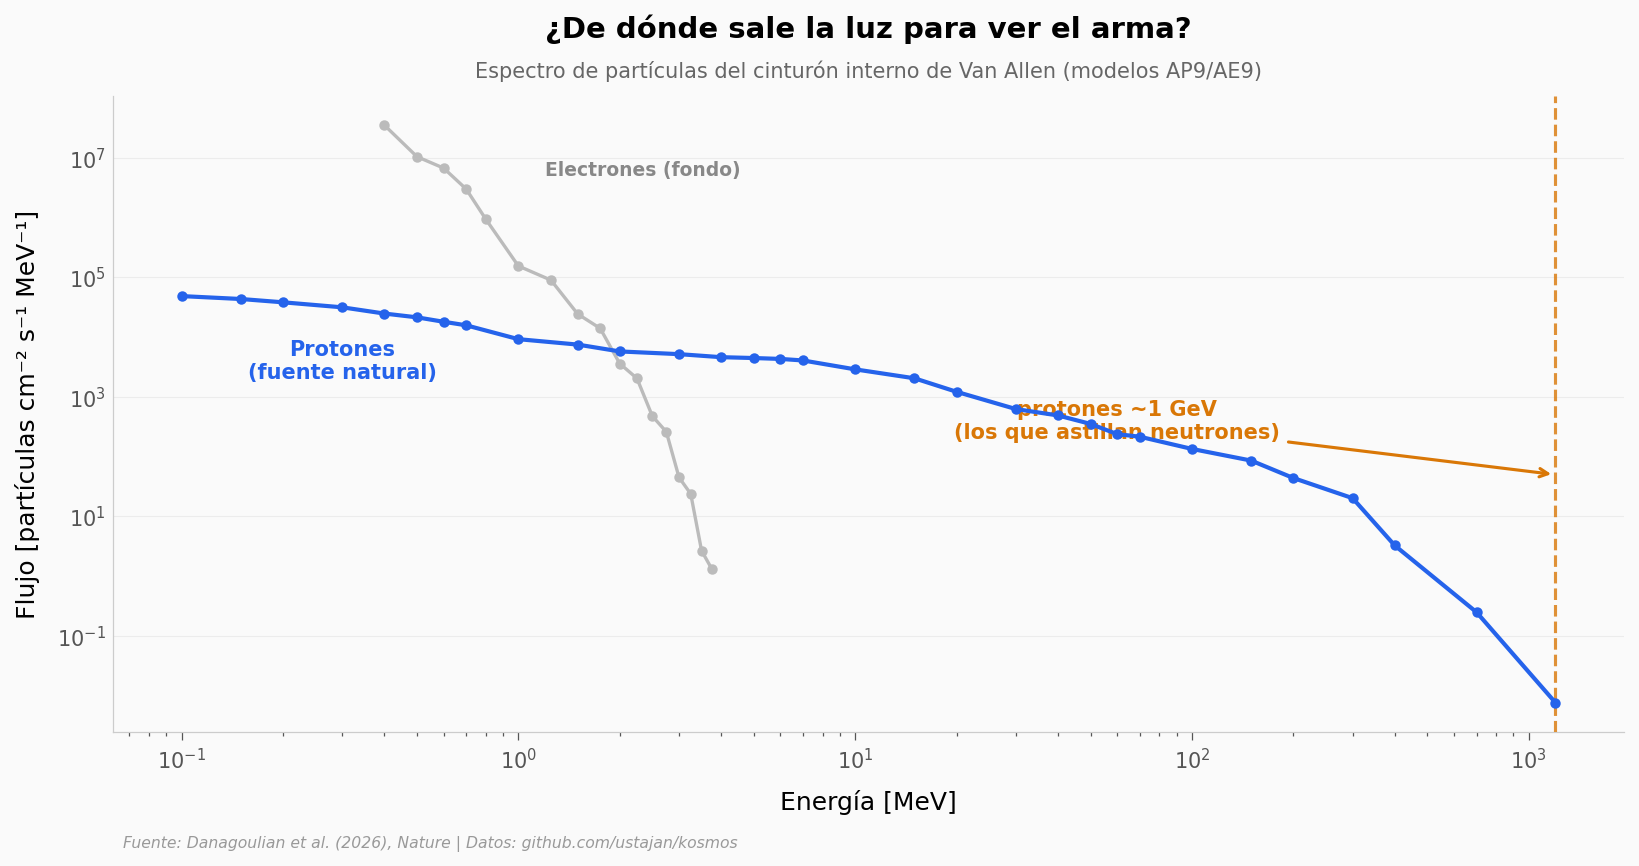

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Electrones: fondo del ambiente (no sirven para astillar neutrones)
ax.plot(elec[:, 0], elec[:, 1], color=COLOR_ELECTRON, linewidth=1.6,
        marker='o', markersize=4, zorder=3)
# Protones: la fuente natural
ax.plot(prot[:, 0], prot[:, 1], color=COLOR_PROTON, linewidth=2.0,
        marker='o', markersize=4, zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')

# Zona de protones ~1 GeV: los únicos con energía para astillar neutrones
ax.axvline(x=1200, color=COLOR_GEV, linewidth=1.5, linestyle='--', alpha=0.8, zorder=4)
ax.annotate('protones ~1 GeV\n(los que astillan neutrones)',
            xy=(1200, 5e1), xytext=(60, 2e2),
            fontsize=10, fontweight='bold', color=COLOR_GEV, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_GEV, lw=1.5))

# Etiquetas inline (sin caja de leyenda)
ax.text(0.3, 2e3, 'Protones\n(fuente natural)', fontsize=10,
        color=COLOR_PROTON, fontweight='bold', ha='center')
ax.text(1.2, 5e6, 'Electrones (fondo)', fontsize=9,
        color='#888888', fontweight='bold', ha='left')

ax.set_title('¿De dónde sale la luz para ver el arma?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Espectro de partículas del cinturón interno de Van Allen (modelos AP9/AE9)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Energía [MeV]')
ax.set_ylabel('Flujo [partículas cm⁻² s⁻¹ MeV⁻¹]')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_protones.png', dpi=200, bbox_inches='tight')
plt.show()

El flujo se desploma: de unos **48.615** protones por cada franja de energía a 0,1 MeV, a apenas **0,0077** cerca de 1.200 MeV. Son siete órdenes de magnitud de caída.

Y sin embargo, los protones que importan son justo esos raros, los de casi 1 GeV. Solo ellos llegan con energía suficiente para romper núcleos y soltar neutrones. Los electrones, mucho más abundantes a baja energía, son demasiado ligeros para eso: forman el fondo, no la herramienta.

## El eco: neutrones

Cuando esos protones golpean el material del arma, sale un chorro de neutrones. Su espectro —simulado con Geant4, un programa que traza partícula por partícula— es la **firma** que el detector buscaría.

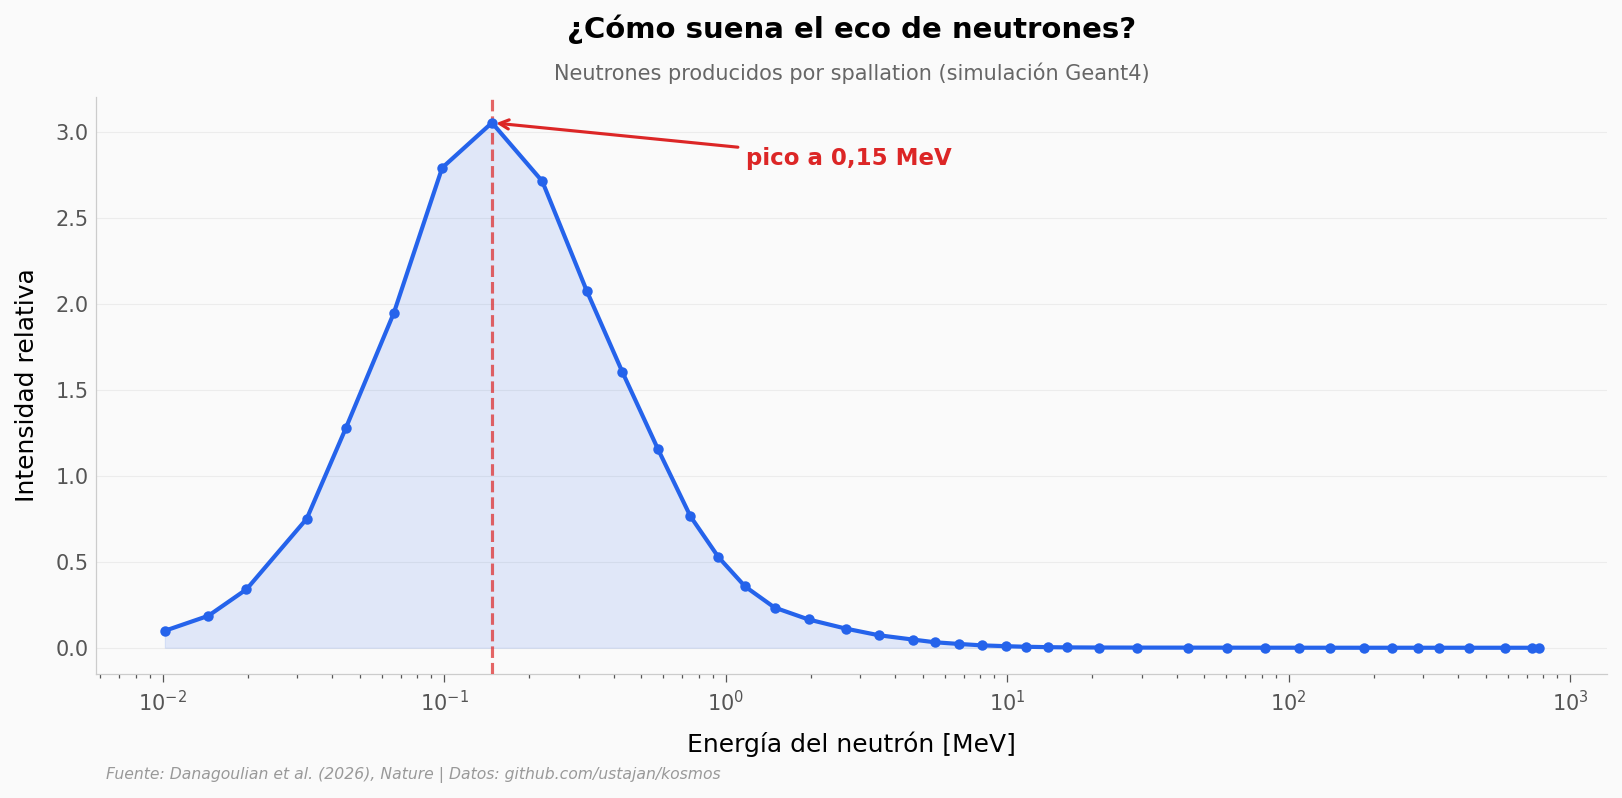

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(neu[:, 0], neu[:, 1], color=COLOR_NEUTRON, linewidth=2.0,
        marker='o', markersize=4, zorder=5)
ax.fill_between(neu[:, 0], neu[:, 1], alpha=0.12, color=COLOR_NEUTRON, zorder=2)
ax.set_xscale('log')

# Marcar el pico
i_pico = np.argmax(neu[:, 1])
e_pico, y_pico = neu[i_pico, 0], neu[i_pico, 1]
ax.axvline(x=e_pico, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7, zorder=4)
ax.annotate(f'pico a {e_pico:.2f} MeV'.replace('.', ','),
            xy=(e_pico, y_pico), xytext=(e_pico*8, y_pico*0.92),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Cómo suena el eco de neutrones?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Neutrones producidos por spallation (simulación Geant4)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Energía del neutrón [MeV]')
ax.set_ylabel('Intensidad relativa')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_neutrones.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Desde qué distancia, y en cuánto tiempo?

Ya hay fuente (protones) y firma (neutrones). Falta lo práctico: ¿a qué distancia puede estar el detector y cuánto tendría que observar? La respuesta del paper es una fórmula sencilla — y tiene una trampa: el tiempo crece con el **cuadrado** de la distancia.

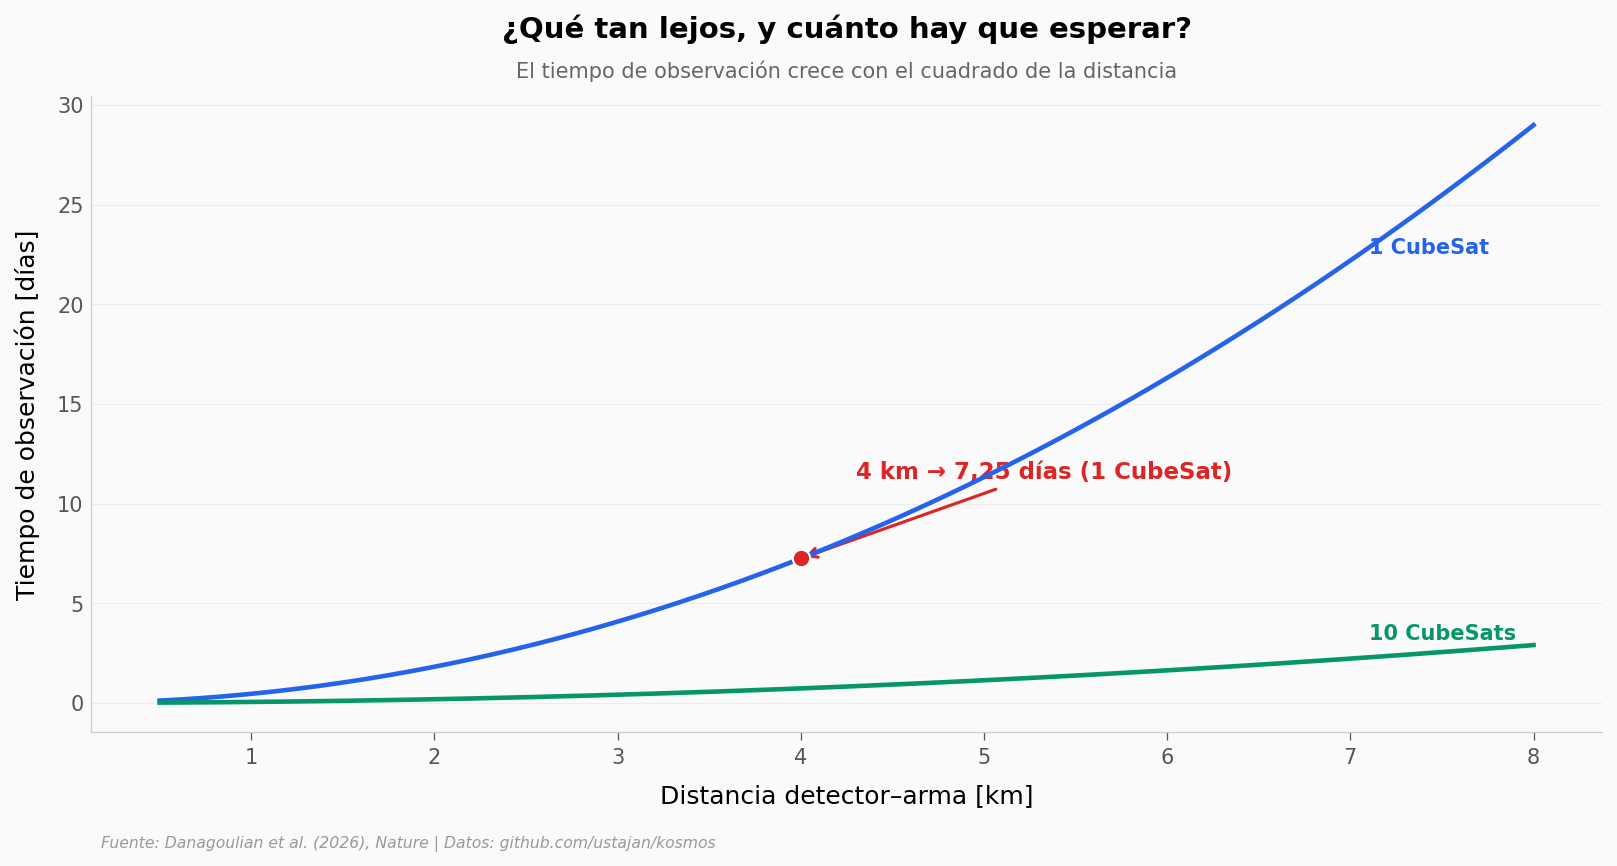

A 4 km: 1 CubeSat = 173.9 h (7.25 d) | 10 CubeSats = 17.4 h (0.72 d)


In [4]:
d_km = np.linspace(0.5, 8.0, 200)
t_n1  = tiempo_deteccion_horas(d_km * 1000, 1) / 24   # días
t_n10 = tiempo_deteccion_horas(d_km * 1000, 10) / 24  # días

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(d_km, t_n1, color=COLOR_PROTON, linewidth=2.2, zorder=5)
ax.plot(d_km, t_n10, color=COLOR_CONSTELACION, linewidth=2.2, zorder=5)

# Punto del abstract: 4 km, 1 CubeSat -> 7,25 días
t4_n1 = tiempo_deteccion_horas(4000, 1) / 24
t4_n10 = tiempo_deteccion_horas(4000, 10) / 24
ax.scatter([4], [t4_n1], color=COLOR_ALERTA, s=70, zorder=6,
           edgecolors='white', linewidths=1.0)
ax.annotate(f'4 km → {t4_n1:.2f} días (1 CubeSat)'.replace('.', ','),
            xy=(4, t4_n1), xytext=(4.3, t4_n1 + 4),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Etiquetas inline de las dos curvas
ax.text(7.1, tiempo_deteccion_horas(7100, 1)/24, '1 CubeSat', fontsize=10,
        color=COLOR_PROTON, fontweight='bold', ha='left', va='center')
ax.text(7.1, tiempo_deteccion_horas(7100, 10)/24 + 1.2, '10 CubeSats', fontsize=10,
        color=COLOR_CONSTELACION, fontweight='bold', ha='left', va='center')

ax.set_title('¿Qué tan lejos, y cuánto hay que esperar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El tiempo de observación crece con el cuadrado de la distancia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Distancia detector–arma [km]')
ax.set_ylabel('Tiempo de observación [días]')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tiempo_vs_distancia.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'A 4 km: 1 CubeSat = {t4_n1*24:.1f} h ({t4_n1:.2f} d) | '
      f'10 CubeSats = {t4_n10*24:.1f} h ({t4_n10:.2f} d)')

## ¿Qué tan cómodo es el punto de 4 km?

El paper elige 4 km y un solo CubeSat: sale ~1 semana. Pero como el tiempo va con d², la ventana cómoda es estrecha. Hagamos un barrido: si el inspector pudiera colocarse a **cualquier** distancia entre 0,5 y 8 km, ¿cuánto tendría que esperar?

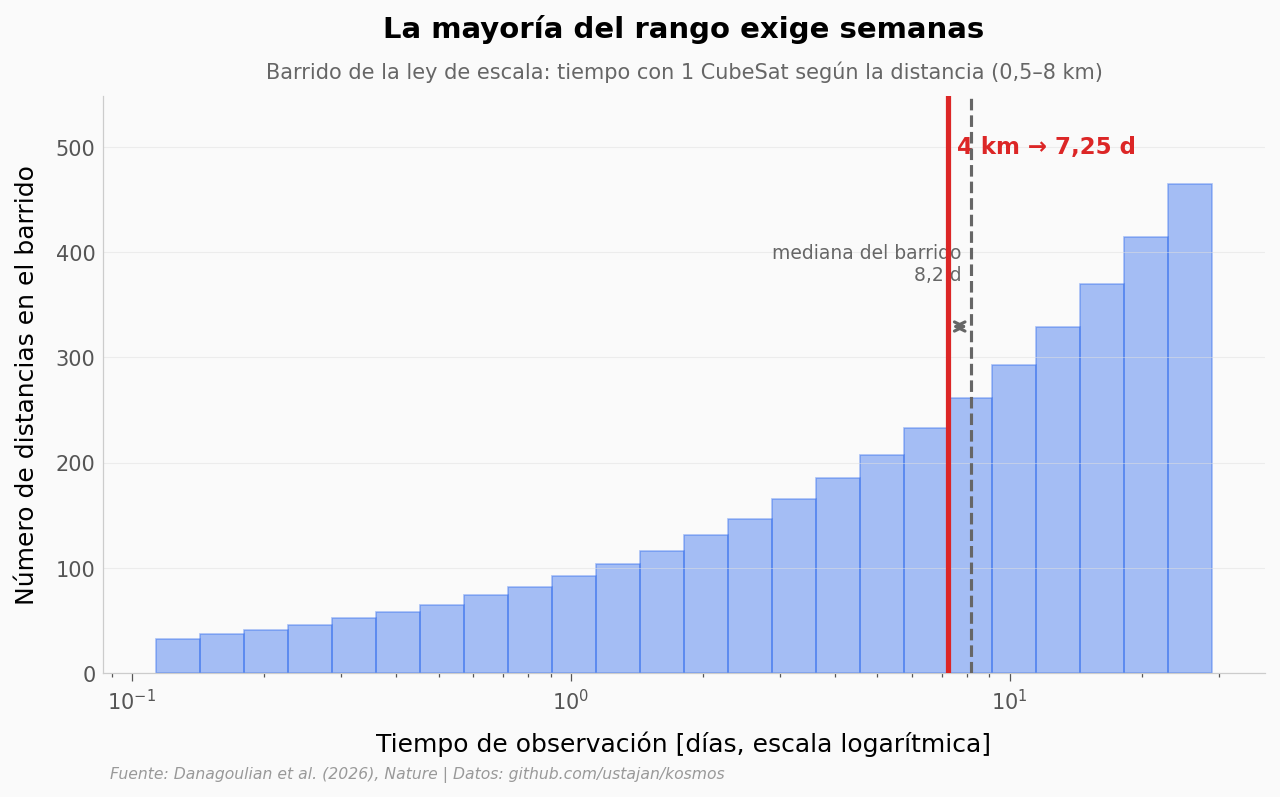

In [5]:
# Barrido: distancias uniformes de 0,5 a 8 km, un solo detector
d_barrido = np.linspace(500, 8000, 4000)
t_barrido = tiempo_deteccion_horas(d_barrido, 1) / 24   # días

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.logspace(np.log10(t_barrido.min()), np.log10(t_barrido.max()), 25)
n, _, _ = ax.hist(t_barrido, bins=bins, color=COLOR_PROTON, alpha=0.4,
                  edgecolor=COLOR_PROTON, linewidth=0.8)
ax.set_xscale('log')
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

t_ref = tiempo_deteccion_horas(4000, 1) / 24   # 7,25 d — punto del abstract
t_med = np.median(t_barrido)
ax.axvline(x=t_ref, color=COLOR_ALERTA, linewidth=2.5, zorder=5)
ax.axvline(x=t_med, color='#666666', linewidth=1.5, linestyle='--', zorder=4)
ax.annotate('', xy=(t_ref, y_max*0.6), xytext=(t_med, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(t_ref*1.05, y_max*0.9, f'4 km → {t_ref:.2f} d'.replace('.', ','),
        fontsize=11, fontweight='bold', color=COLOR_ALERTA)
ax.text(t_med*0.95, y_max*0.68, f'mediana del barrido\n{t_med:.1f} d'.replace('.', ','),
        fontsize=9, color='#666666', ha='right')

ax.set_title('La mayoría del rango exige semanas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Barrido de la ley de escala: tiempo con 1 CubeSat según la distancia (0,5–8 km)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo de observación [días, escala logarítmica]')
ax.set_ylabel('Número de distancias en el barrido')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/barrido_distancia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los protones ~1 GeV del cinturón pueden astillar neutrones de un arma | ✅ Sí | Es física de spallation conocida; el paper la simula con Geant4. El espectro de neutrones (pico a 0,15 MeV) sale de esa simulación |
| Un CubeSat 9U identificaría el arma a 4 km en ~1 semana | ⚠️ En simulación | La ley de escala da 7,25 días a 4 km con 1 detector — reproduce el titular del abstract. Es un cálculo, no una medición en órbita |
| Con 10 CubeSats el tiempo baja a ~17 horas | ⚠️ En simulación | Sale de dividir por n=10 en la misma fórmula. Mismo estatus: cálculo |
| Este método ya verifica el Tratado del Espacio Exterior | ❌ No | Es un estudio conceptual y de viabilidad. No hay hardware volado ni validación en órbita |

> **Limitaciones:** (1) Todo son simulaciones (Geant4) y una fórmula analítica; ningún detector ha volado. (2) La ley de escala asume un arma termonuclear concreta y un punto orbital fijo del cinturón interno. (3) El flujo de protones viene de un modelo de ambiente (AP9/Irene), no de medidas en el momento de una inspección. (4) Los 4 km y la '~1 semana' son el mejor caso presentado; distancias mayores disparan el tiempo, porque crece con d².

### Ahora tú

El cuaderno es tuyo. Tres preguntas para la celda de abajo:

1. **¿Y si el arma está más lejos?** Cambia `distancia = 8000`. Como el tiempo va con d², ¿cuántas veces más hay que esperar respecto a 4 km? (pista: no es el doble)
2. **¿Cuántos CubeSats para bajar de un día?** Sube `n_detectores` a 4 km hasta que el tiempo caiga por debajo de 24 horas. ¿Cuántos hacen falta?
3. **¿Dónde está el límite práctico?** Busca la distancia a la que, con 1 solo detector, el tiempo pasa de un mes. ¿Seguiría siendo útil ahí?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Cambia estos dos valores y corre la celda
distancia   = 8000    # metros
n_detectores = 1

horas = tiempo_deteccion_horas(distancia, n_detectores)
print(f'A {distancia/1000:.1f} km con {n_detectores} CubeSat(s):')
print(f'  {horas:.1f} horas  =  {horas/24:.2f} días')
print(f'  {horas / (tiempo_deteccion_horas(4000, 1)):.1f}x lo que costaría a 4 km')

# ¿Cuántos CubeSats bastan a 4 km para bajar de 24 h?
for n in range(1, 21):
    h = tiempo_deteccion_horas(4000, n)
    if h < 24:
        print(f'\nA 4 km bastan {n} CubeSats para bajar de 24 h ({h:.1f} h)')
        break

A 8.0 km con 1 CubeSat(s):
  695.6 horas  =  28.98 días
  4.0x lo que costaría a 4 km

A 4 km bastan 8 CubeSats para bajar de 24 h (21.7 h)


---

**Paper:** Danagoulian et al. (2026). *Verification of the Outer Space Treaty with cosmic protons*. Nature. [DOI: 10.1038/s41586-026-10783-2](https://doi.org/10.1038/s41586-026-10783-2)  
**Datos y simulación:** [github.com/ustajan/kosmos](https://github.com/ustajan/kosmos) — inputs Geant4, geometría y análisis en Python/Jupyter.  
**Licencia:** datos abiertos del repositorio · notebook CC BY 4.0  
**Repo del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [Verification of the Outer Space Treaty with cosmic protons](https://doi.org/10.1038/s41586-026-10783-2)  
*Nature, 2026-07-08*

**Datos**: [kosmos — Geant4 simulation inputs, geometry and Python/Jupyter analysis package for OST verification](https://github.com/ustajan/kosmos)

*13 afirmaciones verificadas contra estas fuentes*